# 01 Descriptive Analysis and Visualizations
This notebook loads the cleaned analysis dataset and produces descriptive statistics 
and visualizations examining digital access among Kenyan women by wealth, education, 
and urban/rural residence.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

analysis_data = pd.read_csv('../analysis_data.csv')

wealth_order = [1, 2, 3, 4, 5]
edu_order = ['No education', 'Primary', 'Secondary', 'Higher']

analysis_data.head()

,phone_owns,internet_use,wealth_quintile,education,urban_rural,maternal_age
0,1,0,4,No education,Urban,34
1,1,1,5,Secondary,Urban,38
2,1,1,5,Primary,Urban,33
3,1,1,5,Secondary,Urban,39
4,1,1,4,Primary,Urban,30


### Overall Rates

In [29]:
print(f"Overall phone ownership rate: {analysis_data['phone_owns'].mean()*100:.1f}%")
print(f"Overall internet use rate: {analysis_data['internet_use'].mean()*100:.1f}%")

Overall phone ownership rate: 74.7%
Overall internet use rate: 36.9%


### Digital Access by Wealth Quintile

In [31]:
phone_by_wealth = (analysis_data.groupby('wealth_quintile')['phone_owns']
                   .agg(['mean', 'count'])
                   .reindex(wealth_order)
                   .assign(pct_phone=lambda x: (x['mean']*100).round(1))
                   .rename(columns={'count': 'n'})[['pct_phone', 'n']])

internet_by_wealth = (analysis_data.groupby('wealth_quintile')['internet_use']
                      .agg(['mean', 'count'])
                      .reindex(wealth_order)
                      .assign(pct_internet=lambda x: (x['mean']*100).round(1))
                      .rename(columns={'count': 'n'})[['pct_internet', 'n']])

print("Phone Ownership by Wealth Quintile")
print(phone_by_wealth)
print("\nInternet Use by Wealth Quintile")
print(internet_by_wealth)

Phone Ownership by Wealth Quintile
                 pct_phone     n
wealth_quintile                 
1                     54.3  7073
2                     66.8  5742
3                     76.4  6345
4                     85.4  7160
5                     92.5  5836

Internet Use by Wealth Quintile
                 pct_internet     n
wealth_quintile                    
1                         5.4  7073
2                        17.1  5742
3                        31.9  6345
4                        53.7  7160
5                        79.5  5836


### Digital Access by Education Level

In [33]:
phone_by_edu = (analysis_data.groupby('education')['phone_owns']
                .agg(['mean', 'count'])
                .reindex(edu_order)
                .assign(pct_phone=lambda x: (x['mean']*100).round(1))
                .rename(columns={'count': 'n'})[['pct_phone', 'n']])

internet_by_edu = (analysis_data.groupby('education')['internet_use']
                   .agg(['mean', 'count'])
                   .reindex(edu_order)
                   .assign(pct_internet=lambda x: (x['mean']*100).round(1))
                   .rename(columns={'count': 'n'})[['pct_internet', 'n']])

print("Phone Ownership by Education")
print(phone_by_edu)
print("\nInternet Use by Education")
print(internet_by_edu)

Phone Ownership by Education
              pct_phone      n
education                     
No education       66.2   3836
Primary            69.3  11807
Secondary          73.0  11634
Higher             98.8   4879

Internet Use by Education
              pct_internet      n
education                        
No education           4.9   3836
Primary               16.8  11807
Secondary             45.2  11634
Higher                90.9   4879


### Digital Access by Urban/Rural Residence

In [35]:
urban_rural_summary = (analysis_data.groupby('urban_rural')
                       .agg(
                           pct_phone=('phone_owns', lambda x: round(x.mean()*100, 1)),
                           pct_internet=('internet_use', lambda x: round(x.mean()*100, 1)),
                           n=('phone_owns', 'count'))
                       .reset_index())

print(urban_rural_summary)

  urban_rural  pct_phone  pct_internet      n
0       Rural       68.4          24.3  19770
1       Urban       85.0          56.9  12386


## Visualizations

### Figure 1: Phone Ownership vs Internet Use by Wealth Quintile
This shows the gap between phone ownership and internet use at each wealth level, with internet use being lower than phone ownership across all groups. This suggests that owning a phone does not necessarily mean people have equal access to or use of digital services.

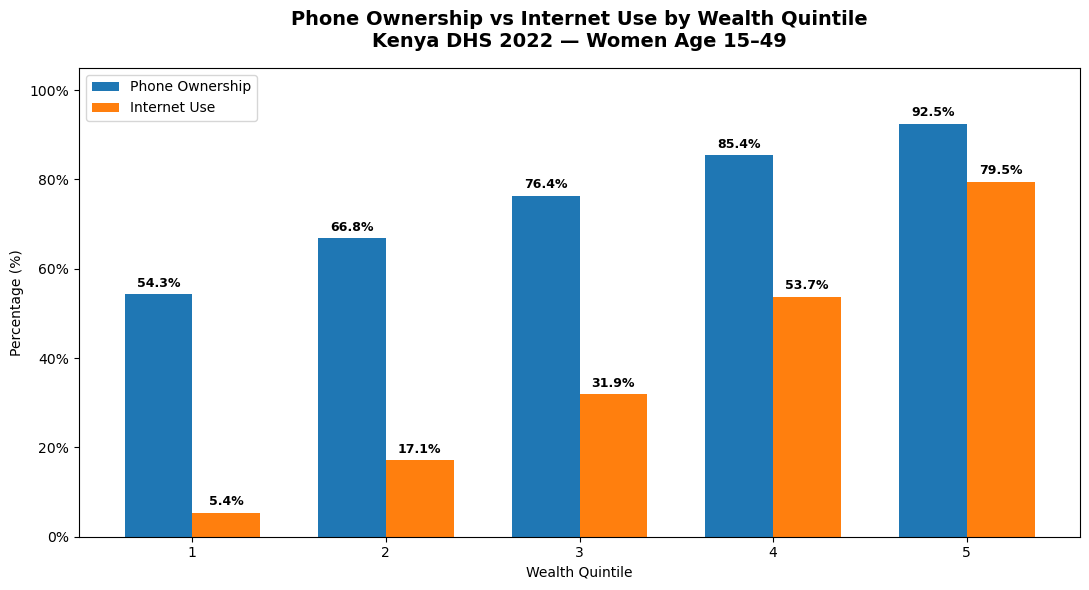

In [37]:
x = np.arange(len(wealth_order))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(x - width/2, phone_by_wealth['pct_phone'].values, width, label='Phone Ownership')
bars2 = ax.bar(x + width/2, internet_by_wealth['pct_internet'].values, width, label='Internet Use')

for bar, val in zip(bars1, phone_by_wealth['pct_phone'].values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1,
            f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

for bar, val in zip(bars2, internet_by_wealth['pct_internet'].values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1,
            f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 105)
ax.set_xticks(x)
ax.set_xticklabels(wealth_order)
ax.set_title('Phone Ownership vs Internet Use by Wealth Quintile\nKenya DHS 2022 — Women Age 15–49',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Wealth Quintile')
ax.set_ylabel('Percentage (%)')
ax.legend()

plt.tight_layout()
plt.savefig('../output/phone_vs_internet_wealth.png', dpi=300, bbox_inches='tight')
plt.show()

### Figure 2: Urban/Rural Comparison

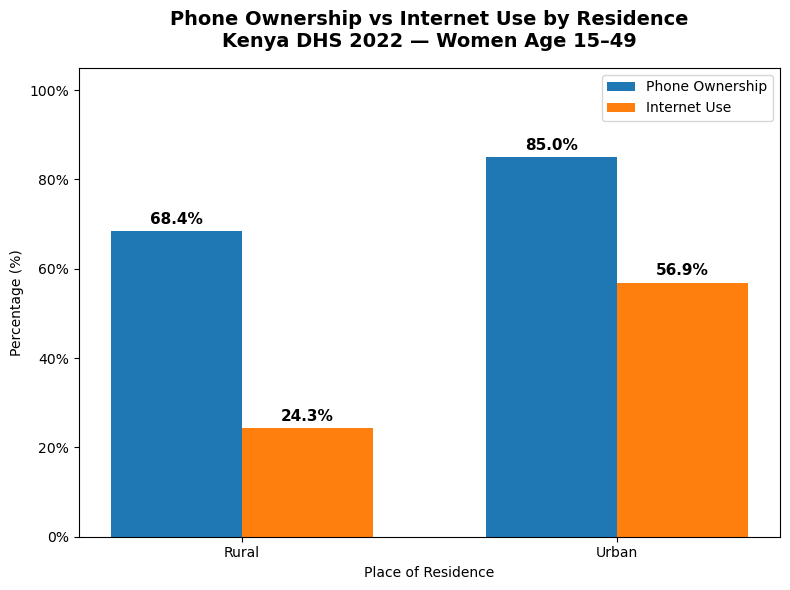

In [39]:
x = np.arange(2)
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))

bars1 = ax.bar(x - width/2, urban_rural_summary['pct_phone'].values, width, label='Phone Ownership')
bars2 = ax.bar(x + width/2, urban_rural_summary['pct_internet'].values, width, label='Internet Use')

for bar, val in zip(bars1, urban_rural_summary['pct_phone'].values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1,
            f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

for bar, val in zip(bars2, urban_rural_summary['pct_internet'].values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1,
            f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 105)
ax.set_xticks(x)
ax.set_xticklabels(['Rural', 'Urban'])
ax.set_title('Phone Ownership vs Internet Use by Residence\nKenya DHS 2022 — Women Age 15–49',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Place of Residence')
ax.set_ylabel('Percentage (%)')
ax.legend()

plt.tight_layout()
plt.savefig('../output/phone_vs_internet_urban_rural.png', dpi=300, bbox_inches='tight')
plt.show()